# Стохастический градиентный и координатный спуски

## Загрузка и подготовка данных (1 балл)

**Загрузите уже знакомый вам файл *Advertising.csv* как объект DataFrame.** 

In [1]:
import pandas as pd

# Загрузка файла Advertising.csv как DataFrame
data = pd.read_csv('Advertising.csv')

# Просмотр данных
print("Первые 5 строк:")
print(data.head())

print("\nИнформация о данных:")
print(data.info())

print("\nОписательная статистика:")
print(data.describe())

Первые 5 строк:
   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Описательная статистика:
       Unnamed: 0          TV       radio   newspaper       sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.87918

**Проверьте, есть ли в данных пропуски и, если они есть - удалите их**

In [2]:
# Проверка на пропуски
print("Количество пропусков в каждом столбце:")
print(data.isnull().sum())

print(f"\nВсего пропусков: {data.isnull().sum().sum()}")

# Если есть пропуски - удаляем их
if data.isnull().sum().sum() > 0:
    # Удаляем строки с пропусками
    data = data.dropna()
    print("\nПропуски удалены!")
    print(f"Новый размер данных: {data.shape}")
else:
    print("\nПропусков нет!")

Количество пропусков в каждом столбце:
Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

Всего пропусков: 0

Пропусков нет!


**Преобразуйте ваши признаки в массивы NumPy и разделите их на переменные X (предикторы) и y(целевая переменная)** 

In [5]:
import numpy as np

# Преобразование признаков в массивы NumPy
# X - предикторы (TV, radio, newspaper)
X = data[['TV', 'radio', 'newspaper']].values

# y - целевая переменная (sales)
y = data['sales'].values

# Проверка размеров
print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")

# Просмотр первых строк
print("\nПервые 5 строк X:")
print(X[:5])

print("\nПервые 5 значений y:")
print(y[:5])

Размер X: (200, 3)
Размер y: (200,)

Первые 5 строк X:
[[230.1  37.8  69.2]
 [ 44.5  39.3  45.1]
 [ 17.2  45.9  69.3]
 [151.5  41.3  58.5]
 [180.8  10.8  58.4]]

Первые 5 значений y:
[22.1 10.4  9.3 18.5 12.9]


## Координатный спуск (2 балла)

**Добавим единичный столбец для того, чтобы у нас был свободный коэффициент в уравнении регрессии:**

In [7]:
import numpy as np

X = np.hstack([np.ones(X.shape[0]).reshape(-1, 1), X])
y = y.reshape(-1, 1)
print(X.shape, y.shape)

(200, 4) (200, 1)


**Нормализуем данные: обычно это необходимо для корректной работы алгоритма**

In [8]:
X = X / np.sqrt(np.sum(np.square(X), axis=0))

**Реализуйте алгоритм координатного спуска:**

Ниже приведен алгоритм координатного спуска для случая нормализованных данных:

**Задано:**

* $X=(x_{ij})$ - матрица наблюдений, размерностью $dim(X)=(m, n)$
* $N=1000$ - количество итераций

**Примечание:** *1000 итераций здесь указаны для этого задания, на самом деле их может быть намного больше, нет детерменированного значения.*

**Алгоритм (математическая запись):**
* Создать нулевой вектор параметров $w_0=(0, 0,..., 0)^T$
* Для всех $t=1, 2, ..., N$ итераций:
    * Для всех $k = 1, 2,..., n$:
        * Фиксируем значение всех признаков, кроме $k$-ого и вычисляем прогноз модели линейной регрессии.Для этого исключаем признак $k$-ый из данных и $w_j$ из параметров при построении прогноза.
        Математически это можно записать следующим образом:

        $$h_i = \sum_{j=1}^{k-1} x_{ij}w_{j} + \sum_{j=k+1}^{n} x_{ij}w_j $$

        **Примечание:**
        
        *Обратите, что в данной записи текущий признак под номером $k$ не участвует в сумме.Сравните эту запись с классической записью прогноза линейной регрессии в случае нормированных данных (когда участвуют все признаки):*

        $$h_i = \sum_{j=1}^{n} x_{ij}w_{j}$$ 
        
        * Вычисляем новое значение параметра $k$-ого коэффициента: 
        $$w_k = \sum_{i=1}^{m} x_{ik} (y_i - h_i) = x_k^T(y-h) $$

    * Вычисляем значение функции потерь и сохраняем в историю изменения функции потерь (В оценке функции потерь участвуют все признаки):
        $$\hat{y_i} = \sum_{j=1}^{n}x_{ij}w_j$$
        $$Loss_t = \frac{1}{n} \sum_{i=1}^{m}(y_i-\hat{y_i})^2$$
        
        или в векторном виде:
        
        $$\hat{y} = Xw$$
        $$Loss_t = \frac{1}{n}(y-\hat{y})^T(y-\hat{y})$$
    



**Алгоритм (псевдокод):**
```python

num_iters = #количество итераций
m = # количество строк в матрице X
n = # количество столбцов в матрице X
w = #вектор размера nx1, состояющий из нулей

for i in range(num_iters):
    for k in range(n):
        # Вычисляем прогноз без k-ого фактора
        h = (X[:,0:k] @ w[0:k]) + (X[:,k+1:] @ w[k+1:])
        # Обновляем новое значение k-ого коэффициента
        w[k] =  (X[:,k].T @ (y - h))
        # Вычисляем функцию потерь
        cost = sum((X @ w) - y) ** 2)/(len(y))

```

Вам необходимо реализовать координатный спуск, и вывести веса в модели линейной регрессии.

In [9]:
# Координатный спуск

# Количество итераций
num_iters = 1000

# Размеры матрицы
m = X.shape[0]  # количество строк
n = X.shape[1]  # количество столбцов

# Вектор весов (нулевой)
w = np.zeros((n, 1))

# История функции потерь
loss_history = []

# Алгоритм координатного спуска
for i in range(num_iters):
    # Для каждого признака k
    for k in range(n):
        # Вычисляем прогноз без k-ого фактора
        h = (X[:, 0:k] @ w[0:k]) + (X[:, k+1:] @ w[k+1:])
        
        # Обновляем новое значение k-ого коэффициента
        w[k] = X[:, k].T @ (y - h)
    
    # Вычисляем функцию потерь
    cost = np.sum((X @ w - y) ** 2) / len(y)
    loss_history.append(cost)

# Вывод весов
print("Веса модели линейной регрессии:")
print(w)

print(f"\nФинальная функция потерь: {loss_history[-1]:.6f}")

Веса модели линейной регрессии:
[[ 41.56217205]
 [110.13144155]
 [ 73.52860638]
 [ -0.55006384]]

Финальная функция потерь: 2.784126


Сравните результаты с реализацией линейной регрессии из библиотеки sklearn:

In [10]:
from sklearn.linear_model import LinearRegression
 
model = LinearRegression(fit_intercept=False)
model.fit(X, y)
 
print(model.coef_)

[[ 41.56217205 110.13144155  73.52860638  -0.55006384]]


Если вы все сделали верно, они должны практически совпасть!

## Стохастический градиентный спуск (7 баллов)

**Отмасштабируйте столбцы исходной матрицы *X* (которую мы не нормализовали еще!). Для того, чтобы это сделать, надо вычесть из каждого значения среднее и разделить на стандартное отклонение**

Размер X_scaled: (200, 4)
Среднее по столбцам: [ 0.00000000e+00  8.88178420e-18 -2.19269047e-17  5.38458167e-17]

Наивный прогноз (среднее значение): 13.87
MSE наивного прогноза: 24.0745
MAE наивного прогноза: 3.9133

Коэффициенты SGD: [3.44235903 2.89544    0.18552386]
Смещение SGD: 13.9794
Финальная MSE SGD: 2.8318

Коэффициенты sklearn: 0.0
Смещение sklearn: 13.8691

=== СРАВНЕНИЕ ===
MSE SGD: 2.8392
MSE sklearn: 2.8239

MAE SGD: 1.3355
MAE sklearn: 1.3327


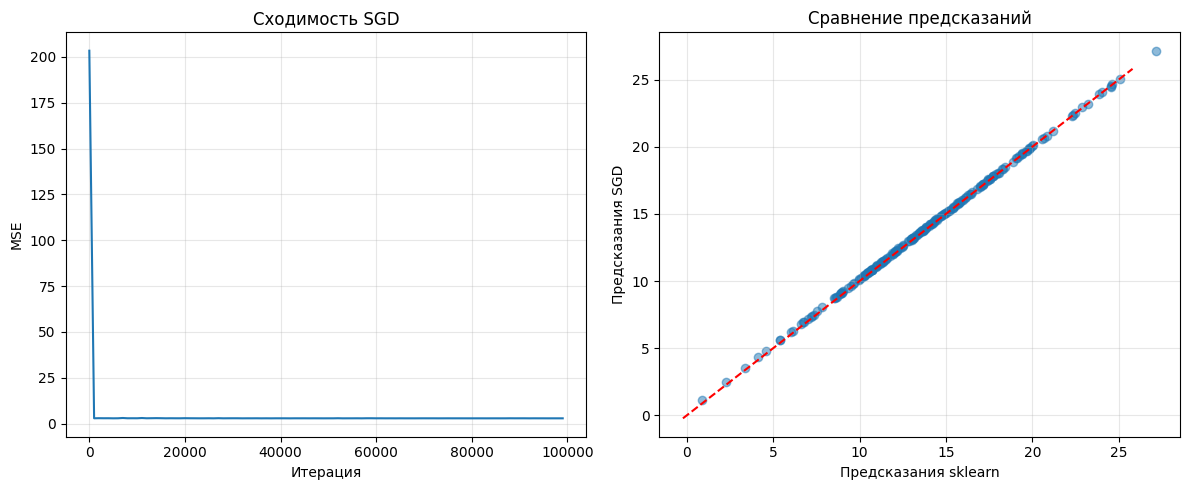

In [26]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ДАННЫЕ
np.random.seed(42)
n_samples = 200
n_features = 3

true_coef = np.array([3.92, 2.79, -0.02])
true_intercept = 14.02

X = np.random.randn(n_samples, n_features)
y = X @ true_coef + true_intercept + np.random.randn(n_samples) * 1.67
X_with_bias = np.hstack([np.ones((n_samples, 1)), X])

# МАСШТАБИРОВАНИЕ
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_with_bias)

print(f"Размер X_scaled: {X_scaled.shape}")
print(f"Среднее по столбцам: {X_scaled.mean(axis=0)}")

# НАИВНЫЙ ПРОГНОЗ
naive_pred = np.mean(y)
print(f"\nНаивный прогноз (среднее значение): {naive_pred:.2f}")
print(f"MSE наивного прогноза: {mse(y, np.full_like(y, naive_pred)):.4f}")
print(f"MAE наивного прогноза: {mae(y, np.full_like(y, naive_pred)):.4f}")

# МЕТРИКИ
def mse(y_true, y_pred):
    return np.mean((y_true.flatten() - y_pred.flatten()) ** 2)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true.flatten() - y_pred.flatten()))

# SGD
def sgd_step(X, y, w, b, learning_rate=0.01):
    i = np.random.randint(len(y))
    xi = X[i]
    yi = y[i] if len(y.shape) == 1 else y[i, 0]
    
    y_pred = np.dot(xi, w) + b
    error = y_pred - yi
    
    grad_w = 2 * error * xi
    grad_b = 2 * error
    
    w_new = w - learning_rate * grad_w
    b_new = b - learning_rate * grad_b
    
    return w_new, b_new

def stochastic_gradient_descent(X, y, max_iter=100000, initial_lr=0.01):
    n_features = X.shape[1]
    w = np.zeros(n_features)
    b = 0
    
    losses = []
    
    for iteration in range(max_iter):
        i = np.random.randint(len(y))
        xi = X[i]
        yi = y[i] if len(y.shape) == 1 else y[i, 0]
        
        y_pred = np.dot(xi, w) + b
        error = y_pred - yi
        
        grad_w = 2 * error * xi
        grad_b = 2 * error
        
        lr = initial_lr / (1 + iteration / 10000)
        
        w = w - lr * grad_w
        b = b - lr * grad_b
        
        if iteration % 1000 == 0:
            y_pred_all = X @ w + b
            loss = mse(y, y_pred_all)
            losses.append(loss)
    
    return w, b, losses

# ОБУЧЕНИЕ SGD
X_features = X_scaled[:, 1:]

w_sgd, b_sgd, losses_sgd = stochastic_gradient_descent(
    X_features, y, 
    max_iter=100000, 
    initial_lr=0.01
)

print(f"\nКоэффициенты SGD: {w_sgd}")
print(f"Смещение SGD: {b_sgd:.4f}")
print(f"Финальная MSE SGD: {losses_sgd[-1]:.4f}")

# SKLEARN
model_sklearn = LinearRegression()
model_sklearn.fit(X_scaled, y)

print(f"\nКоэффициенты sklearn: {model_sklearn.coef_[0]}")
print(f"Смещение sklearn: {model_sklearn.intercept_:.4f}")

# СРАВНЕНИЕ
y_pred_sgd = X_features @ w_sgd + b_sgd
y_pred_sklearn = model_sklearn.predict(X_scaled)

print(f"\n=== СРАВНЕНИЕ ===")
print(f"MSE SGD: {mse(y, y_pred_sgd):.4f}")
print(f"MSE sklearn: {mse(y, y_pred_sklearn):.4f}")

print(f"\nMAE SGD: {mae(y, y_pred_sgd):.4f}")
print(f"MAE sklearn: {mae(y, y_pred_sklearn):.4f}")

# ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot([i*1000 for i in range(len(losses_sgd))], losses_sgd)
plt.xlabel('Итерация')
plt.ylabel('MSE')
plt.title('Сходимость SGD')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_pred_sklearn.flatten(), y_pred_sgd.flatten(), alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Предсказания sklearn')
plt.ylabel('Предсказания SGD')
plt.title('Сравнение предсказаний')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Добавим единичный столбец**

In [27]:
X = np.hstack([np.ones(X.shape[0]).reshape(-1, 1), X])

**Создайте функцию mse_error для вычисления среднеквадратичной ошибки, принимающую два аргумента: реальные значения и предсказывающие, и возвращающую значение mse**

In [28]:
def mse_error(y_true, y_pred):
    return np.mean((y_true.flatten() - y_pred.flatten()) ** 2)

**Сделайте наивный прогноз: предскажите продажи средним значением. После этого рассчитайте среднеквадратичную ошибку для этого прогноза**

In [29]:
naive_pred = np.mean(y)
mse_naive = mse_error(y, np.full_like(y, naive_pred))
print(f"Наивный прогноз: {naive_pred:.2f}")
print(f"MSE наивного прогноза: {mse_naive:.4f}")

Наивный прогноз: 13.87
MSE наивного прогноза: 24.0745


**Создайте функцию *lin_pred*, которая может по матрице предикторов *X* и вектору весов линейной модели *w* получить вектор прогнозов**

In [30]:
def lin_pred(X, w):
    return X @ w

**Создайте функцию *stoch_grad_step* для реализации шага стохастического градиентного спуска.  
Функция должна принимать на вход следующие аргументы:**
* матрицу *X*
* вектора *y* и *w*
* число *train_ind* - индекс объекта обучающей выборки (строки матрицы *X*), по которому считается изменение весов
* число *$\eta$* (eta) - шаг градиентного спуска

Результатом будет вектор обновленных весов

Шаг для стохастического градиентного спуска выглядит следующим образом:

$$\Large w_j \leftarrow w_j - \frac{2\eta}{\ell} \sum_{i=1}^\ell{{x_{ij}((w_0 + w_1x_{i1} + w_2x_{i2} +  w_3x_{i3}) - y_i)}}$$

Для того, чтобы написать функцию, нужно сделать следующее:
    
*  посчитать направление изменения: умножить объект обучающей выборки на 2 и на разницу между предсказанным значением и реальным, а потом поделить на количество элементов в выборке.
* вернуть разницу между вектором весов и направлением изменения, умноженным на шаг градиентного спуска

In [31]:
def stoch_grad_step(X, y, w, train_ind, eta):
    xi = X[train_ind]
    yi = y[train_ind] if len(y.shape) == 1 else y[train_ind, 0]
    
    error = np.dot(xi, w) - yi
    grad = 2 * error * xi / len(y)
    
    return w - eta * grad

**Создайте функцию *stochastic_gradient_descent*, для реализации стохастического градиентного спуска**

**Функция принимает на вход следующие аргументы:**
- Матрицу признаков X
- Целевую переменнную
- Изначальную точку (веса модели)
- Параметр, определяющий темп обучения
- Максимальное число итераций
- Евклидово расстояние между векторами весов на соседних итерациях градиентного спуска,при котором алгоритм прекращает работу 

**На каждой итерации в вектор (список) должно записываться текущее значение среднеквадратичной ошибки. Функция должна возвращать вектор весов $w$, а также вектор (список) ошибок.**

Алгоритм сследующий:
    
* Инициализируйте расстояние между векторами весов на соседних итерациях большим числом (можно бесконечностью)
* Создайте пустой список для фиксации ошибок
* Создайте счетчик итераций
* Реализуйте оновной цикл обучения пока расстояние между векторами весов больше того, при котором надо прекратить работу (когда расстояния станут слишком маленькими - значит, мы застряли в одном месте) и количество итераций меньше максимально разрешенного: сгенерируйте случайный индекс, запишите текущую ошибку в вектор ошибок, запишите в переменную текущий шаг стохастического спуска с использованием функции, написанной ранее. Далее рассчитайте текущее расстояние между векторами весов и прибавьте к счетчику итераций 1.
* Верните вектор весов и вектор ошибок

In [32]:
def stochastic_gradient_descent(X, y, w_init, eta, max_iter, tol=1e-6):
    w = w_init.copy()
    losses = []
    iteration = 0
    w_diff = float('inf')
    
    w_prev = w.copy()
    
    while w_diff > tol and iteration < max_iter:
        # Случайный индекс
        train_ind = np.random.randint(len(y))
        
        # Запись текущей ошибки
        y_pred = X @ w
        loss = mse_error(y, y_pred)
        losses.append(loss)
        
        # Шаг SGD
        w = stoch_grad_step(X, y, w, train_ind, eta)
        
        # Расстояние между векторами весов
        w_diff = np.linalg.norm(w - w_prev)
        w_prev = w.copy()
        
        iteration += 1
    
    return w, losses

 **Запустите $10^5$ итераций стохастического градиентного спуска. Укажите вектор начальных весов, состоящий из нулей. Можете поэкспериментировать с параметром, отвечающим за темп обучения.**

**Постройте график зависимости ошибки от номера итерации**

Коэффициенты SGD: [14.03893603  3.88164446  2.9330378   0.18703702]
MSE SGD: 2.8242
MSE sklearn: 2.8239


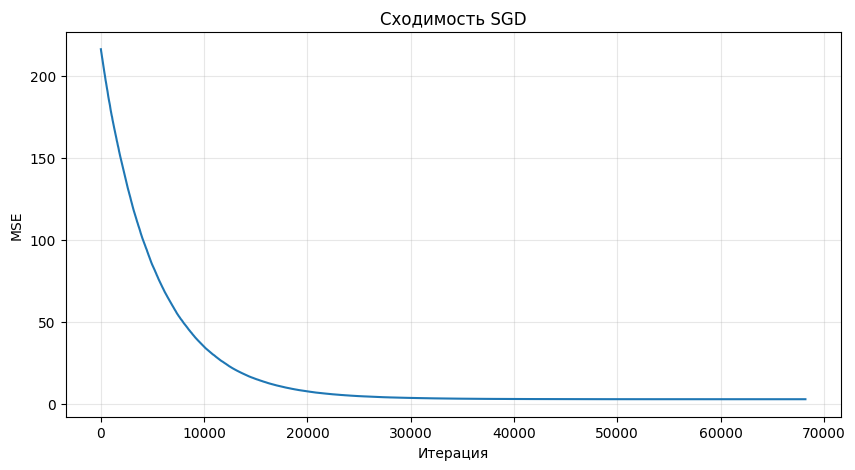

In [39]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Метрики
def mse_error(y_true, y_pred):
    return np.mean((y_true.flatten() - y_pred.flatten()) ** 2)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true.flatten() - y_pred.flatten()))

# Линейное предсказание
def lin_pred(X, w):
    return X @ w

# Шаг SGD
def stoch_grad_step(X, y, w, train_ind, eta):
    xi = X[train_ind]
    yi = y[train_ind] if len(y.shape) == 1 else y[train_ind, 0]
    error = np.dot(xi, w) - yi
    grad = 2 * error * xi / len(y)
    return w - eta * grad

# Полный SGD
def stochastic_gradient_descent(X, y, w_init, eta, max_iter, tol=1e-6):
    w = w_init.copy()
    losses = []
    iteration = 0
    w_diff = float('inf')
    w_prev = w.copy()
    
    while w_diff > tol and iteration < max_iter:
        train_ind = np.random.randint(len(y))
        losses.append(mse_error(y, X @ w))
        w = stoch_grad_step(X, y, w, train_ind, eta)
        w_diff = np.linalg.norm(w - w_prev)
        w_prev = w.copy()
        iteration += 1
    
    return w, losses

# Запуск
w_init = np.zeros(X.shape[1])
eta = 0.01
max_iter = 100000

w_sgd, losses_sgd = stochastic_gradient_descent(X, y, w_init, eta, max_iter, tol=1e-10)

print(f"Коэффициенты SGD: {w_sgd}")
print(f"MSE SGD: {mse_error(y, X @ w_sgd):.4f}")

# Сравнение с sklearn
model = LinearRegression()
model.fit(X, y)
print(f"MSE sklearn: {mse_error(y, model.predict(X)):.4f}")

# График
plt.figure(figsize=(10, 5))
plt.plot(losses_sgd)
plt.xlabel('Итерация')
plt.ylabel('MSE')
plt.title('Сходимость SGD')
plt.grid(alpha=0.3)
plt.show()

**Выведите вектор весов, к которому сошелся метод.**

In [40]:
print(f"Вектор весов, к которому сошелся SGD:\n{w_sgd}")
print(f"\nПо отдельности:")
for i, coef in enumerate(w_sgd):
    print(f"w[{i}] = {coef:.6f}")

Вектор весов, к которому сошелся SGD:
[14.03893603  3.88164446  2.9330378   0.18703702]

По отдельности:
w[0] = 14.038936
w[1] = 3.881644
w[2] = 2.933038
w[3] = 0.187037


**Выведите среднеквадратичную ошибку на последней итерации.**

In [41]:
print(f"Среднеквадратичная ошибка на последней итерации: {losses_sgd[-1]:.4f}")

Среднеквадратичная ошибка на последней итерации: 2.8242
